# 04 — Full flight: flapping to gliding transition

<div style="display: flex; flex-direction: row; width: 100%; justify-content: space-between; margin-bottom: 10px;">
  <img src="figures/04_full_modes_0.gif" style="width: 50%;"/>
  <img src="figures/04_full_modes_1.gif" style="width: 50%;"/>
</div>

This notebook analyses the full flight trajectory of Toothless at 9 m, capturing the continuous transition from flapping to gliding. Unlike the previous notebooks, which examined steady-state flapping only, the data here span take-off through mid-flight flapping to a terminal glide.

We fit DMD to the entire trajectory, then separately to the gliding phase alone, to examine how mode structure changes when flapping ceases.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget
%config InlineBackend.figure_format='svg'

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import SVG, display
from morphing_birds import Animal3D, animate, animate_plotly_compare

from birddmd import (
    plot_mode_dynamics,
    reconstruct,
    run_dmd,
)

In [2]:
hawk3d = Animal3D("hawk", "../data/mean_hawk_shape.csv")
average_shape = hawk3d.markers
n_markers = 8

## 1 — Full flight DMD

The full-flight data cover roughly 0.1–1.35 s, binned from repeated sequences of Toothless at 9 m. The shaded overview plot below shows mean ± s.d. across sequences for each marker coordinate. The transition from high-amplitude flapping to low-amplitude gliding is visible around 0.7–0.8 s.

The preparation script (`scripts/prepare_full_flight.py`) bins the raw full-flight and gliding sequences. Expand the cell below to review the pipeline.

In [3]:
# %load scripts/prepare_full_flight.py

In [4]:
loaded_data = np.load("../data/processed/Toothless_full_flight_binned.npz")
markers_full, times_full = loaded_data["markers_full"], loaded_data["times_full"]

print(
    f"Full flight: {markers_full.shape[0]} frames, "
    f"{times_full[0]:.2f}s to {times_full[-1]:.2f}s"
)

Full flight: 250 frames, 0.10s to 1.35s


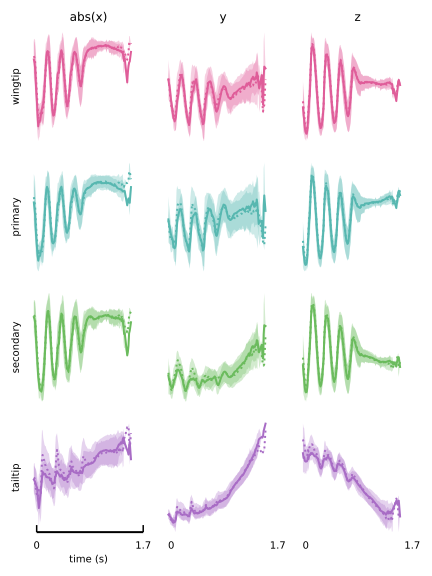

In [5]:
display(SVG("figures/04_full_flight_overview.svg"))

Running DMD with 4 modes, delay d=2
Input shape: (250, 24)
Number of variables in DMD results: 48
Complex Eigenvalues (log): [-2.038+28.638j -2.038-28.638j  0.78  +1.419j  0.78  -1.419j]
Number of modes in Psi: 4
Pair 1 (0,1) Frequency: 4.56 Hz | f=4.56 Hz | λ=-2.038+28.638j
Pair 2 (2,3) Frequency: 0.23 Hz | f=0.23 Hz | λ=0.780+1.419j


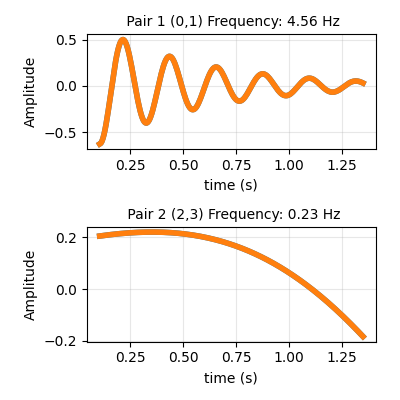

In [6]:
N_MODES_FULL = 4
D = 2

result_full = run_dmd(
    data=markers_full,
    times=times_full,
    n_modes=N_MODES_FULL,
    d=D,
    eig_constraints={"conjugate_pairs"},
    n_markers=n_markers,
    average_shape=average_shape,
    verbose=True,
)

fig = plot_mode_dynamics(
    times_full[1:],
    result_full,
    axes_visible=True,
)
fig.savefig("figures/04_full_flight_dynamics.svg", format="svg")

In [7]:
# Reconstruct each conjugate pair separately
conjugate_pairs = result_full.conjugate_pairs
pair_labels = ["Flapping", "Glide & Landing"]
pair_colours = ["#57B7B0", "#DF5D99"]

mode_keypoints = []
for pair_idx in range(len(conjugate_pairs)):
    kp = reconstruct(result_full, times=times_full[1:], pairs=[pair_idx])
    mode_keypoints.append(kp)
    i, j = conjugate_pairs[pair_idx]
    print(f"Pair {pair_idx + 1} ({pair_labels[pair_idx]}): modes ({i},{j})")

Pair 1 (Flapping): modes (0,1)
Pair 2 (Glide & Landing): modes (2,3)


In [8]:
# # Save each as a gif
# for pair_idx, (kp, label, colour) in enumerate(
#     zip(mode_keypoints, pair_labels, pair_colours)
# ):
#     ani = animate(hawk3d, kp, colour=colour, az=50, el=30)
#     _ = ani.save(
#         f"figures/04_full_modes_{pair_idx}.gif",
#         writer="Pillow", fps=40, dpi=300,
#     )
#     print("Saved GIF")

<img src="figures/04_full_modes_0.gif" width="300"/>
<img src="figures/04_full_modes_1.gif" width="300"/>



In [9]:
# hawk3d = Animal3D('hawk', "../data/mean_hawk_shape.csv")

# animate_plotly_compare(
#     hawk3d,
#     keypoints_frames_list=mode_keypoints,
#     colours=pair_colours,
# )

## 2 — Gliding-only DMD

Here we isolate the gliding phase (approximately 0.78–1.35 s) and fit DMD with only 4 modes (2 conjugate pairs). Fewer modes suffice because flapping oscillations are absent; the dynamics are dominated by slow postural adjustments as the bird extends its wings and decelerates.

In [10]:
markers_glide, times_glide = loaded_data["markers_glide"], loaded_data["times_glide"]
print(f"Gliding: {markers_glide.shape[0]} frames")

Gliding: 114 frames


Running DMD with 4 modes, delay d=2
Input shape: (114, 24)
Number of variables in DMD results: 48
Complex Eigenvalues (log): [  0.197 +1.182j   0.197 -1.182j -18.762+17.1j   -18.762-17.1j  ]
Number of modes in Psi: 4
Pair 1 (0,1) Frequency: 0.19 Hz | f=0.19 Hz | λ=0.197+1.182j
Pair 2 (2,3) Frequency: 2.72 Hz | f=2.72 Hz | λ=-18.762+17.100j


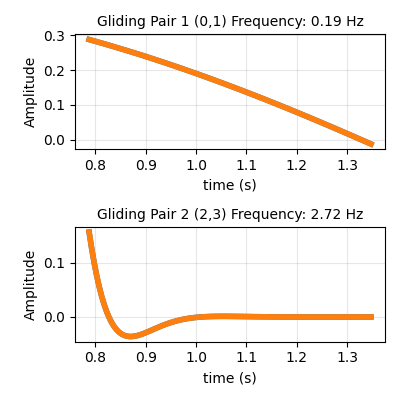

In [11]:
result_glide = run_dmd(
    data=markers_glide,
    times=times_glide,
    n_modes=4,
    d=D,
    eig_constraints={"conjugate_pairs"},
    n_markers=n_markers,
    average_shape=average_shape,
    verbose=True,
)

fig = plot_mode_dynamics(
    times_glide[1:],
    result_glide,
    title_prefix="Gliding",
    axes_visible=True,
)
fig.savefig("figures/04_gliding_dynamics.svg", format="svg")

In [12]:
# Reconstruct each conjugate pair separately
conjugate_pairs = result_glide.conjugate_pairs
pair_labels = ["Glide & Pitch Up", "Final Wingbeat"]
pair_colours = ["#DF5D99", "#57B7B0"]

mode_keypoints = []
for pair_idx in range(len(conjugate_pairs)):
    kp = reconstruct(result_glide, times=times_glide[1:], pairs=[pair_idx])
    mode_keypoints.append(kp)
    i, j = conjugate_pairs[pair_idx]
    print(f"Pair {pair_idx + 1} ({pair_labels[pair_idx]}): modes ({i},{j})")

Pair 1 (Glide & Pitch Up): modes (0,1)
Pair 2 (Final Wingbeat): modes (2,3)


In [13]:
# # Save each as a gif
# for pair_idx, (kp, label, colour) in enumerate(
#     zip(mode_keypoints, pair_labels, pair_colours)
# ):
#     ani = animate(hawk3d, kp, colour=colour, az=50, el=30)
#     _ = ani.save(
#         f"figures/04_gliding_modes_{pair_idx}.gif",
#         writer="Pillow", fps=40, dpi=300,
#     )
#     print("Saved GIF")

<img src="figures/04_gliding_modes_1.gif" width="300"/>
<img src="figures/04_gliding_modes_0.gif" width="300"/>


In [14]:
# hawk3d = Animal3D('hawk', "../data/mean_hawk_shape.csv")

# animate_plotly_compare(
#     hawk3d,
#     keypoints_frames_list=mode_keypoints,
#     colours=pair_colours,
# )

## Next steps

Forecasting and extrapolation using stabilised DMD eigenvalues are covered in `07_generative_model`. The next notebook (`05_turning`) examines obstacle-avoidance flights, where asymmetric banking introduces modes not present in straight flight.